In [ ]:
import pandas as pd
import numpy as np

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier, ExtraTreesClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import accuracy_score, classification_report

# SMOTE
from imblearn.over_sampling import SMOTE


# ===============================
# 🔹 Load Dataset
# ===============================
df = pd.read_csv("/content/heart_disease_uci(Present).csv")

# Handle missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

# Encode categorical
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col])

# Target handling
if 'target' in df.columns:
    y = df['target']
    X = df.drop('target', axis=1)
else:
    y = df['num'].apply(lambda x: 1 if x > 0 else 0)
    X = df.drop('num', axis=1)


# ===============================
# 🔹 Scaling
# ===============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ===============================
# 🔹 Feature Selection
# ===============================
selector = SelectKBest(score_func=f_classif, k=12)
X_selected = selector.fit_transform(X_scaled, y)


# ===============================
# 🔹 Handle Imbalance
# ===============================
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_selected, y)


# ===============================
# 🔹 Train-Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)


# ===============================
# 🔹 Model 1: KNN with GridSearch
# ===============================
knn = KNeighborsClassifier()

param_grid = {
    'n_neighbors': [5,7,9,11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid = GridSearchCV(knn, param_grid, cv=5)
grid.fit(X_train, y_train)
best_knn = grid.best_estimator_


# ===============================
# 🔹 Model 2: Gradient Boosting
# ===============================
gb = GradientBoostingClassifier(n_estimators=200)


# ===============================
# 🔹 Model 3: XGBoost
# ===============================
xgb = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)


# ===============================
# 🔹 Model 4: Extra Trees
# ===============================
et = ExtraTreesClassifier(n_estimators=300, random_state=42)


# ===============================
# 🔹 Voting Ensemble (Level 1)
# ===============================
voting = VotingClassifier(
    estimators=[
        ('knn', best_knn),
        ('gb', gb),
        ('xgb', xgb)
    ],
    voting='soft'
)


# ===============================
# 🔹 Final Hybrid (Stacking)
# ===============================
final_model = StackingClassifier(
    estimators=[
        ('voting', voting),
        ('et', et)
    ],
    final_estimator=LogisticRegression(),
    cv=5
)


# ===============================
# 🔹 Train
# ===============================
final_model.fit(X_train, y_train)


# ===============================
# 🔹 Predict
# ===============================
y_pred = final_model.predict(X_test)


# ===============================
# 🔹 Results
# ===============================
print("🔥 Hybrid Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

🔥 Hybrid Model Accuracy: 0.8823529411764706

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.91      0.88        95
           1       0.91      0.86      0.89       109

    accuracy                           0.88       204
   macro avg       0.88      0.88      0.88       204
weighted avg       0.88      0.88      0.88       204



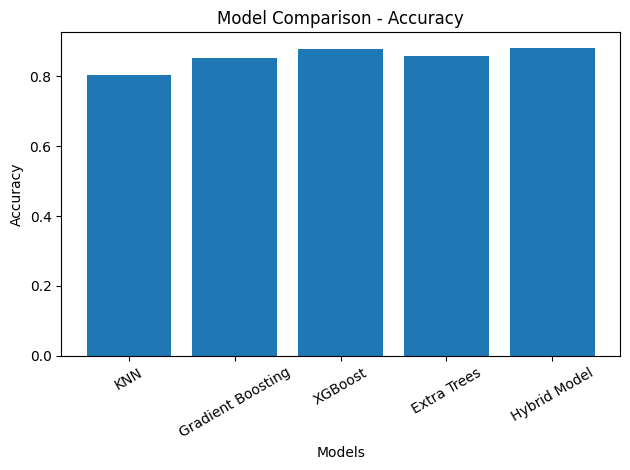

In [ ]:
import matplotlib.pyplot as plt

# Make sure models are trained
knn_model = grid.best_estimator_
gb.fit(X_train, y_train)
xgb.fit(X_train, y_train)
et.fit(X_train, y_train)

models = ['KNN', 'Gradient Boosting', 'XGBoost', 'Extra Trees', 'Hybrid Model']

accuracies = [
    knn_model.score(X_test, y_test),
    gb.score(X_test, y_test),
    xgb.score(X_test, y_test),
    et.score(X_test, y_test),
    final_model.score(X_test, y_test)
]

plt.figure()
plt.bar(models, accuracies)
plt.xlabel('Models')
plt.ylabel('Accuracy')
plt.title('Model Comparison - Accuracy')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()